<h1 style="color:#56B4E9;">Week 5 - Day 3</h1>

<h2 style="color:#0072B2;">Dimensionality Reduction with PCA</h2>

<h3 style="color:#009E73;">Compressing Patient Features While Preserving Information</h3>

During Days 1 and 2, clustering methods examined patient structure using six selected Cleveland Heart Disease features. The original dataset, however, contains **13 predictor features**, making it difficult to inspect the complete patient representation visually.

This notebook asks two connected questions:

1. **How many principal components are required to retain approximately 95% of the standardized data variance?**
2. **What patient structure remains visible when all predictors are compressed into only two components?**

The workflow will:

- Prepare all 13 predictors without using the diagnosis during PCA fitting.
- demonstrate why scaling is essential for variance-based reduction.
- fit PCA and analyze individual and cumulative explained variance.
- select the minimum component count reaching the 95% threshold.
- produce an accessible 2D PCA visualization using color and marker shape.
- interpret what the reduction preserved and what it cost.

<span style="color:#009E73;"><b>Main goal:</b></span>  
Reduce the Cleveland patient representation responsibly, justify the retained component count with evidence, and document the compression-interpretability trade-off.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
from pathlib import Path

<h2 style="color:#0072B2;">Loading the Cleveland Heart Disease Data</h2>

The same 303-patient dataset from Days 1 and 2 is retained, preserving continuity across the week.

The final column, `num`, is the known diagnosis outcome. It will **not** be included when fitting PCA because PCA is an unsupervised transformation of the predictor matrix `X`. A binary version of the diagnosis will be retained separately only for interpreting the final 2D visualization.

In [2]:
column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"
]

data_paths = [
    "../../processed.cleveland.data",
    "processed.cleveland.data",
    "/tmp/processed.cleveland.data"
]

data_path = next(
    (path for path in data_paths if Path(path).exists()),
    None
)

if data_path is None:
    raise FileNotFoundError(
        "processed.cleveland.data was not found. Place it two directories "
        "above this notebook or in the notebook directory."
    )

data = pd.read_csv(
    data_path,
    header=None,
    names=column_names
)

data = data.replace("?", np.nan)
data = data.apply(pd.to_numeric, errors="coerce")

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


<h2 style="color:#0072B2;">Defining Predictors and the Reference Group</h2>

All 13 predictor columns are used to make dimensionality reduction meaningful. This differs from the six-feature clustering comparison, whose purpose was to keep the Day 1 input unchanged.

The diagnosis is converted into two reference groups:

- `0`: no diagnosed heart disease.
- `1`: heart disease present (`num > 0`).

These labels are **not inputs to PCA**. They are used only after fitting to check whether the unsupervised 2D representation shows any visible separation.

<span style="color:#D55E00;"><b>Important limitation:</b></span>  
Several Cleveland variables are category codes stored numerically. PCA treats all included values as quantitative geometry, so the result is an educational approximation rather than a clinically definitive latent representation.

In [3]:
predictor_features = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal"
]

X = data[predictor_features].copy()
y_reference = (data["num"] > 0).astype(int)

missing_summary = (
    X.isna()
    .sum()
    .to_frame("missing_values")
)

print("Predictor matrix shape:", X.shape)
print("Reference group counts:")
display(y_reference.value_counts().sort_index().rename("patients"))
display(missing_summary[missing_summary["missing_values"] > 0])

Predictor matrix shape: (303, 13)
Reference group counts:


num
0    164
1    139
Name: patients, dtype: int64

,missing_values
ca,4
thal,2


<h2 style="color:#0072B2;">The Curse of Dimensionality</h2>

Each predictor represents one dimension. Therefore, each patient is currently a point in a **13-dimensional feature space**.

As dimensionality increases:

- observations become more sparse;
- distances may become less informative;
- redundant features can add complexity without equivalent new information;
- visualization becomes impossible beyond three dimensions;
- some downstream models may become slower or more vulnerable to overfitting.

PCA addresses this by rotating the coordinate system and constructing new axes called **principal components**. It does not remove patients, and it does not simply select original columns.

Each component is a weighted combination of the original standardized features:

$$
PC_j = w_{j1}x_1 + w_{j2}x_2 + \cdots + w_{jp}x_p
$$

`PC1` captures the greatest possible variance. `PC2` captures the greatest remaining variance while staying perpendicular to `PC1`, and later components follow the same rule.

<h2 style="color:#0072B2;">Handling Missing Values</h2>

PCA cannot operate with missing values. The Cleveland dataset contains four missing values in `ca` and two in `thal`.

Median imputation is retained from the earlier notebooks because it:

- is simple and reproducible;
- is less sensitive to extreme values than mean imputation;
- preserves all 303 patients.

The imputer is fitted only on `X`; the reference diagnosis remains separate.

In [4]:
imputer = SimpleImputer(strategy="median")

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("Missing values before imputation:", X.isna().sum().sum())
print("Missing values after imputation:", X_imputed.isna().sum().sum())
print("Imputed matrix shape:", X_imputed.shape)

Missing values before imputation: 6
Missing values after imputation: 0
Imputed matrix shape: (303, 13)


<h2 style="color:#0072B2;">Why PCA Requires Scaling</h2>

PCA searches for directions with the greatest variance. The original features use very different scales: cholesterol may contain values in the hundreds, while `oldpeak` and several coded variables have much smaller numerical ranges.

Without scaling, a large-range feature can dominate the variance simply because of its measurement scale.

StandardScaler transforms every feature using:

$$
z = \frac{x - \mu}{\sigma}
$$

After transformation, each feature has a mean near zero and a standard deviation near one. This gives the features comparable numerical influence before PCA constructs its components.

In [5]:
unscaled_pca = PCA()
unscaled_pca.fit(X_imputed)

unscaled_pc1_weights = pd.Series(
    np.abs(unscaled_pca.components_[0]),
    index=predictor_features,
    name="absolute_PC1_weight"
).sort_values(ascending=False)

print(
    "Variance attributed to unscaled PC1:",
    f"{unscaled_pca.explained_variance_ratio_[0]:.2%}"
)

unscaled_pc1_weights.head()

Variance attributed to unscaled PC1: 74.65%


chol        0.997968
trestbps    0.050469
age         0.038406
thalach     0.003763
restecg     0.003340
Name: absolute_PC1_weight, dtype: float64

<h3 style="color:#009E73;">Interpreting the Unscaled Experiment</h3>

Without scaling, the first component appears to explain approximately **74.65%** of all variance, but `chol` has an absolute PC1 weight of approximately **0.998**.

This means the apparent compression is misleading: the first component is almost entirely a cholesterol axis because cholesterol has the largest numerical spread.

<span style="color:#D55E00;"><b>Decision:</b></span>  
Standardize every predictor before fitting the PCA model so that the result reflects standardized variation rather than measurement units.

In [6]:
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X_imputed),
    columns=X_imputed.columns,
    index=X_imputed.index
)

scaling_check = X_scaled.describe().loc[["mean", "std"]].round(2)

print("Scaled data shape:", X_scaled.shape)
scaling_check

Scaled data shape: (303, 13)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
mean,-0.0,-0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


<h2 style="color:#0072B2;">Fitting PCA Without Discarding Components</h2>

The first PCA model keeps all 13 components. No reduction is performed yet.

This diagnostic fit is necessary because the number of components should be chosen from the observed cumulative explained variance rather than assumed in advance.

For each component, PCA provides:

- `explained_variance_ratio_`: the fraction of total standardized variance captured by that component;
- cumulative explained variance: the total variance retained by the first component through the current component.

In [7]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

variance_table = pd.DataFrame({
    "component": np.arange(1, len(explained_variance) + 1),
    "explained_variance": explained_variance,
    "cumulative_variance": cumulative_variance
})

variance_table.style.format({
    "explained_variance": "{:.2%}",
    "cumulative_variance": "{:.2%}"
})

,component,explained_variance,cumulative_variance
0,1,23.69%,23.69%
1,2,12.31%,35.99%
2,3,9.53%,45.53%
3,4,8.43%,53.96%
4,5,7.58%,61.54%
5,6,6.79%,68.34%
6,7,6.65%,74.99%
7,8,5.98%,80.97%
8,9,5.29%,86.26%
9,10,4.33%,90.59%


<h2 style="color:#0072B2;">Explained Variance by Component</h2>

The first component should explain the largest share, and every later component can explain no more variance than the component before it.

The bar chart below shows the individual contribution of each component. Exact percentage labels are included so the result does not depend on color alone.

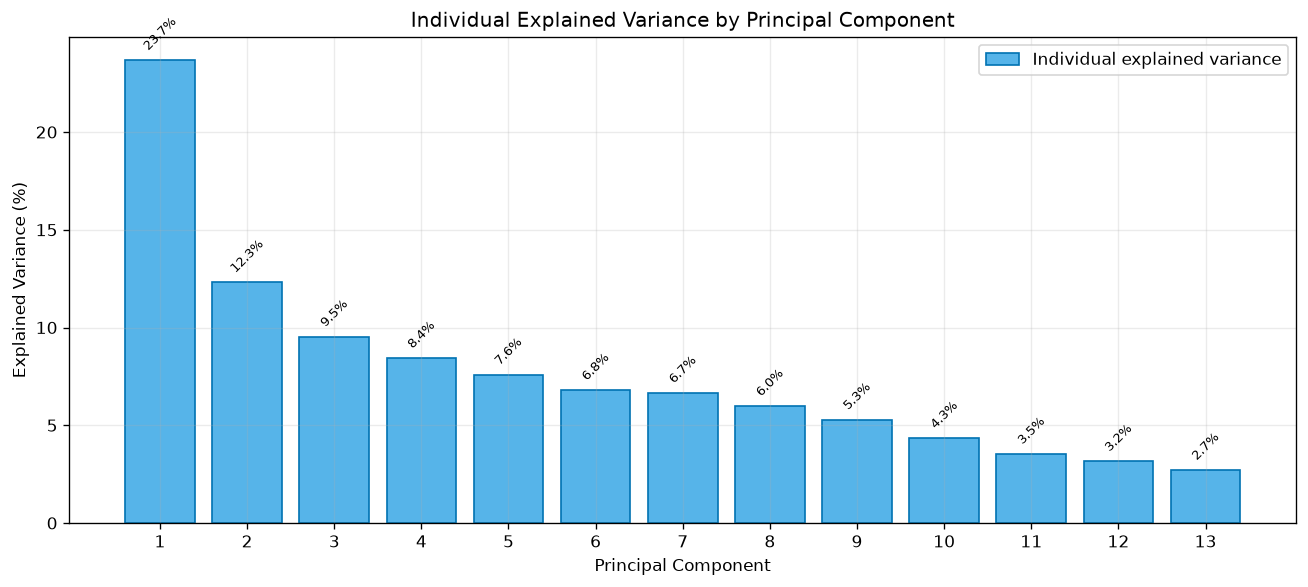

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(
    variance_table["component"],
    variance_table["explained_variance"] * 100,
    color="#56B4E9",
    edgecolor="#0072B2",
    label="Individual explained variance"
)

for bar, value in zip(bars, variance_table["explained_variance"] * 100):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.35,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=45
    )

ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance (%)")
ax.set_title("Individual Explained Variance by Principal Component")
ax.set_xticks(variance_table["component"])
ax.legend()
plt.tight_layout()
plt.show()

<h3 style="color:#009E73;">Interpreting Individual Explained Variance</h3>

After scaling, `PC1` explains approximately **23.69%** of the total variance and `PC2` explains approximately **12.31%**.

Unlike the unscaled experiment, no single component dominates the complete dataset. This indicates that the standardized patient variation is distributed across several directions.

The result also suggests that aggressive compression to only two or three components would discard a substantial amount of the standardized variance.

<h2 style="color:#0072B2;">Selecting the Number of Components</h2>

The Hands-On Lab requires selecting enough components to retain approximately 95% of the variance.

The selected count is therefore the smallest value of $k$ satisfying:

$$
\sum_{j=1}^{k} Explained\ Variance\ Ratio_j \geq 0.95
$$

The cumulative curve provides both the selection evidence and the cost of choosing a smaller representation.

In [9]:
variance_threshold = 0.95

n_components_95 = (
    np.argmax(cumulative_variance >= variance_threshold) + 1
)

retained_variance_95 = cumulative_variance[n_components_95 - 1]

print("Selected component count:", n_components_95)
print("Variance retained:", f"{retained_variance_95:.2%}")
print("Dimensions removed:", X_scaled.shape[1] - n_components_95)

Selected component count: 12
Variance retained: 97.28%
Dimensions removed: 1


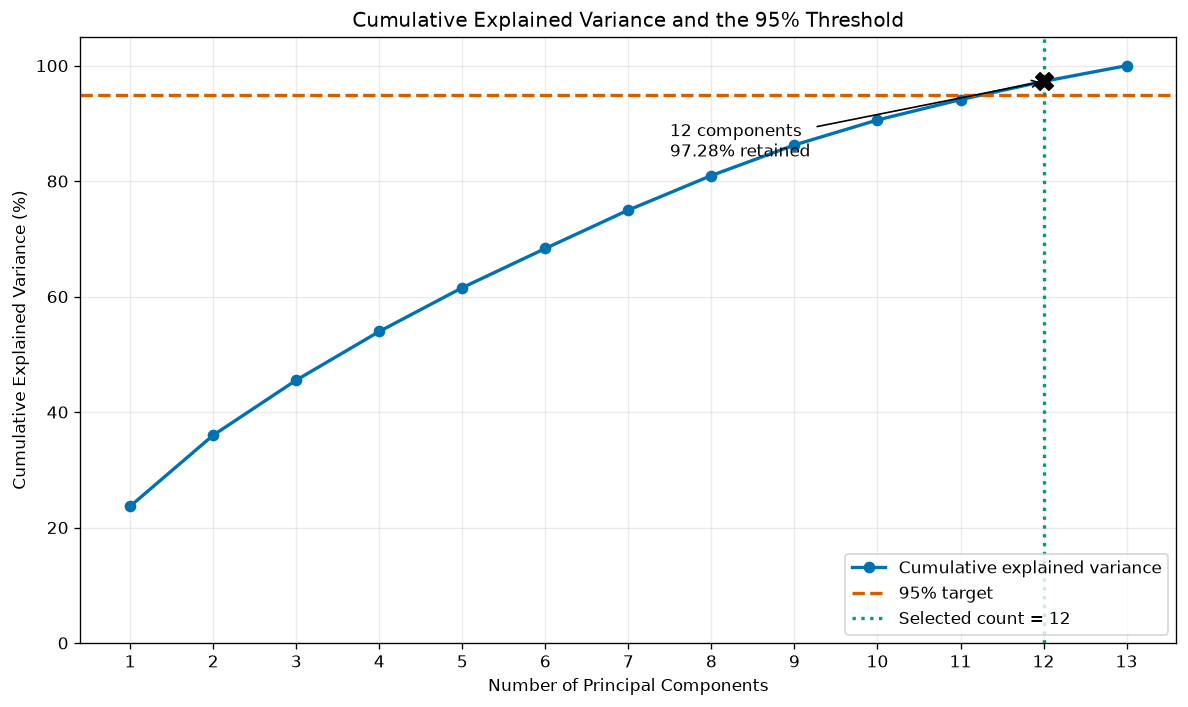

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    variance_table["component"],
    variance_table["cumulative_variance"] * 100,
    color="#0072B2",
    marker="o",
    linewidth=2,
    label="Cumulative explained variance"
)

ax.axhline(
    y=95,
    color="#D55E00",
    linestyle="--",
    linewidth=2,
    label="95% target"
)

ax.axvline(
    x=n_components_95,
    color="#009E73",
    linestyle=":",
    linewidth=2,
    label=f"Selected count = {n_components_95}"
)

ax.scatter(
    n_components_95,
    retained_variance_95 * 100,
    color="#000000",
    marker="X",
    s=110,
    zorder=5
)

ax.annotate(
    f"{n_components_95} components\n{retained_variance_95:.2%} retained",
    xy=(n_components_95, retained_variance_95 * 100),
    xytext=(n_components_95 - 4.5, retained_variance_95 * 100 - 13),
    arrowprops={"arrowstyle": "->", "color": "#000000"},
    fontsize=10
)

ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Explained Variance (%)")
ax.set_title("Cumulative Explained Variance and the 95% Threshold")
ax.set_xticks(variance_table["component"])
ax.set_ylim(0, 105)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

<h3 style="color:#009E73;">Component-Count Decision</h3>

The cumulative curve reaches the 95% target for the first time at **12 components**, retaining approximately **97.28%** of the standardized variance.

Using 11 components would retain only approximately **94.12%**, which is below the selected target. Therefore, 12 is the minimum count that satisfies the stated rule.

This result removes only one of the 13 dimensions. It reveals that the dataset does **not** contain enough linear redundancy for strong compression at such a strict threshold.

<span style="color:#D55E00;"><b>Decision:</b></span>  
Retain 12 components for the 95% representation. The modest reduction is accepted because the threshold is an information-preservation requirement, not a promise of dramatic compression.

<h2 style="color:#0072B2;">Creating the 95% PCA Representation</h2>

A second PCA model is now fitted using the justified component count. The resulting matrix contains the same 303 patients but only 12 transformed dimensions.

This is the representation that would be passed to a downstream model when the goal is to retain at least 95% of standardized variance.

In [11]:
pca_95 = PCA(n_components=n_components_95)
X_pca_95_array = pca_95.fit_transform(X_scaled)

component_names_95 = [
    f"PC{i}" for i in range(1, n_components_95 + 1)
]

X_pca_95 = pd.DataFrame(
    X_pca_95_array,
    columns=component_names_95,
    index=X_scaled.index
)

print("Original standardized shape:", X_scaled.shape)
print("Reduced PCA shape:", X_pca_95.shape)
print(
    "Verified retained variance:",
    f"{pca_95.explained_variance_ratio_.sum():.2%}"
)

X_pca_95.head()

Original standardized shape: (303, 13)
Reduced PCA shape: (303, 12)
Verified retained variance: 97.28%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
0,1.162722,-0.929622,3.212341,2.248647,0.117105,0.164221,0.966571,-0.596128,-1.484567,-0.453161,0.222642,0.497023
1,3.217830,-1.451021,-0.481532,-0.849814,-0.138780,-0.631340,0.403677,1.058591,0.419353,1.475782,-1.032829,-0.942472
2,3.143604,0.636569,-0.364301,-0.607485,0.045832,-1.003931,0.681505,0.185650,0.057853,0.470704,0.340281,0.895176
3,-0.464908,1.409706,0.395323,2.797258,0.874659,-0.160742,-0.644582,-2.159004,0.877933,0.243848,-1.545183,0.170085
4,-2.268663,-0.388683,-0.068956,1.170135,0.839176,-0.141872,0.729038,0.033008,1.067675,0.553453,0.912098,-0.281023


<h2 style="color:#0072B2;">Reducing the Data to Two Components</h2>

The 12-component model satisfies the information-retention objective but cannot be plotted directly.

A separate two-component PCA model is therefore created **for visualization only**. Its purpose is not to replace the 95% representation.

The exact retained variance must be reported because a 2D plot is a compressed projection and cannot display all structure from the original 13-dimensional data.

In [12]:
pca_2d = PCA(n_components=2)
X_pca_2d_array = pca_2d.fit_transform(X_scaled)

X_pca_2d = pd.DataFrame(
    X_pca_2d_array,
    columns=["PC1", "PC2"],
    index=X_scaled.index
)

X_pca_2d["diagnosis_group"] = y_reference.map({
    0: "No Heart Disease",
    1: "Heart Disease"
})

two_component_variance = pca_2d.explained_variance_ratio_.sum()

print("PC1 explained variance:", f"{pca_2d.explained_variance_ratio_[0]:.2%}")
print("PC2 explained variance:", f"{pca_2d.explained_variance_ratio_[1]:.2%}")
print("Total 2D variance retained:", f"{two_component_variance:.2%}")

PC1 explained variance: 23.69%
PC2 explained variance: 12.31%
Total 2D variance retained: 35.99%


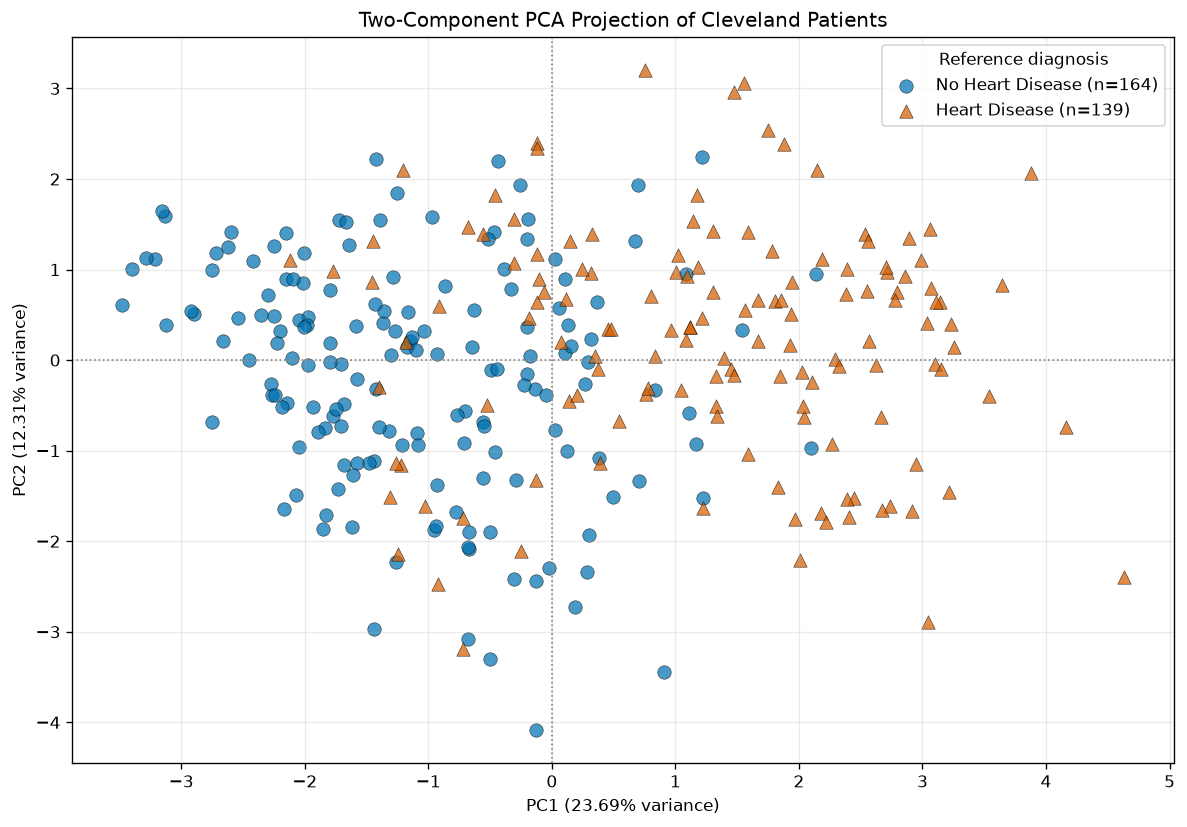

In [13]:
group_styles = {
    "No Heart Disease": {
        "color": "#0072B2",
        "marker": "o"
    },
    "Heart Disease": {
        "color": "#D55E00",
        "marker": "^"
    }
}

fig, ax = plt.subplots(figsize=(10, 7))

for group_name, style in group_styles.items():
    group_data = X_pca_2d[
        X_pca_2d["diagnosis_group"] == group_name
    ]

    ax.scatter(
        group_data["PC1"],
        group_data["PC2"],
        color=style["color"],
        marker=style["marker"],
        s=65,
        alpha=0.72,
        edgecolor="black",
        linewidth=0.35,
        label=f"{group_name} (n={len(group_data)})"
    )

ax.axhline(0, color="gray", linewidth=1, linestyle=":")
ax.axvline(0, color="gray", linewidth=1, linestyle=":")
ax.set_xlabel(
    f"PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)"
)
ax.set_ylabel(
    f"PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)"
)
ax.set_title("Two-Component PCA Projection of Cleveland Patients")
ax.legend(title="Reference diagnosis")
plt.tight_layout()
plt.show()

<h3 style="color:#009E73;">Interpreting the 2D Projection</h3>

The two-dimensional projection retains approximately **35.99%** of the standardized variance: 23.69% in `PC1` and 12.31% in `PC2`.

The diagnosis groups show a visible directional tendency, especially along `PC1`, but they still overlap substantially. This is expected because:

- PCA was fitted without diagnosis labels;
- PCA maximizes predictor variance, not class separation;
- approximately 64% of standardized variance is absent from the 2D view.

The plot is therefore useful for visual exploration, but it is not evidence that two components are sufficient for diagnosis or predictive modeling.

<h2 style="color:#0072B2;">Understanding What the Components Represent</h2>

PCA loadings are the weights used to construct each component from the original standardized features.

Large absolute weights indicate that a feature contributes strongly to a component. The sign shows direction, but the sign of an entire PCA axis can be reversed without changing the represented geometry.

Inspecting loadings partially restores interpretability, although a component still cannot be treated as one original clinical measurement.

In [14]:
loadings_2d = pd.DataFrame(
    pca_2d.components_.T,
    index=predictor_features,
    columns=["PC1_loading", "PC2_loading"]
)

loading_strength = loadings_2d.copy()
loading_strength["PC1_absolute"] = loading_strength["PC1_loading"].abs()
loading_strength["PC2_absolute"] = loading_strength["PC2_loading"].abs()

print("Strongest contributors to PC1:")
display(
    loading_strength
    .sort_values("PC1_absolute", ascending=False)
    .head(6)
    [["PC1_loading", "PC1_absolute"]]
    .round(3)
)

print("Strongest contributors to PC2:")
display(
    loading_strength
    .sort_values("PC2_absolute", ascending=False)
    .head(6)
    [["PC2_loading", "PC2_absolute"]]
    .round(3)
)

Strongest contributors to PC1:
Strongest contributors to PC2:


,PC1_loading,PC1_absolute
oldpeak,0.397,0.397
thalach,-0.389,0.389
slope,0.354,0.354
thal,0.345,0.345
exang,0.333,0.333
ca,0.307,0.307


,PC2_loading,PC2_absolute
sex,0.452,0.452
chol,-0.439,0.439
age,-0.418,0.418
trestbps,-0.377,0.377
thal,0.272,0.272
restecg,-0.269,0.269


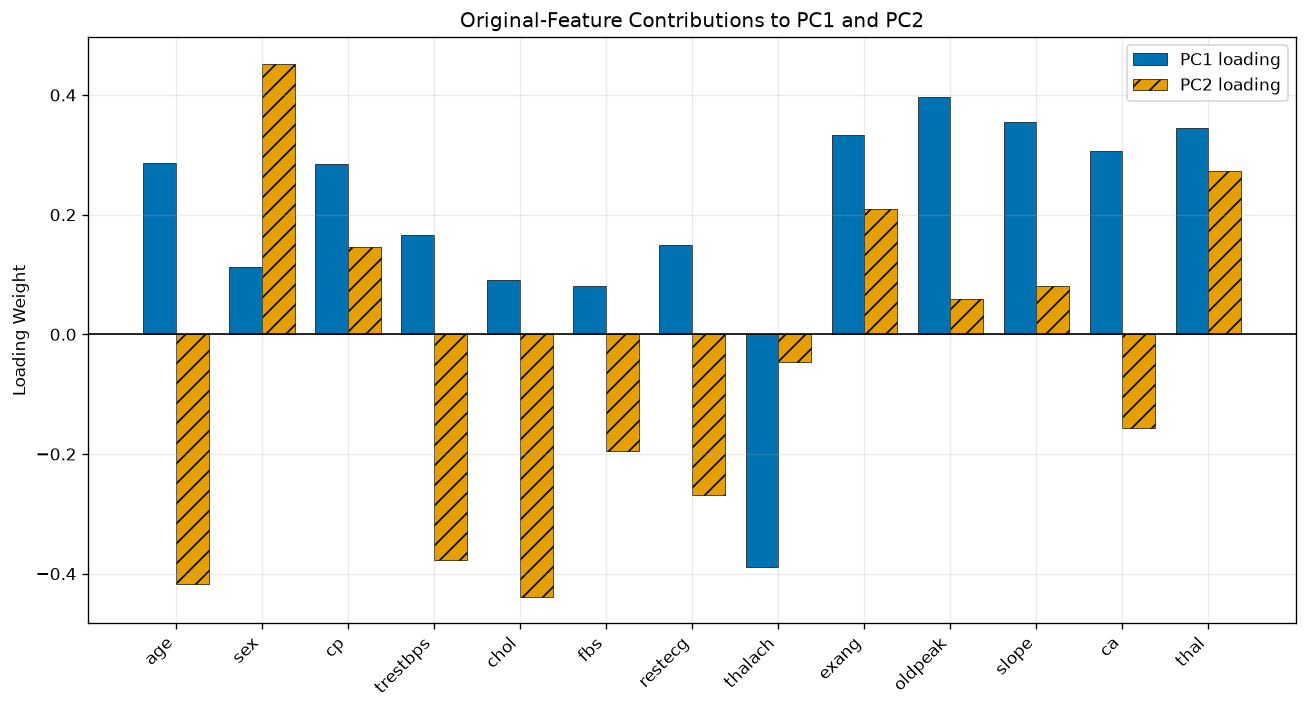

In [15]:
fig, ax = plt.subplots(figsize=(11, 6))

x_positions = np.arange(len(predictor_features))
bar_width = 0.38

ax.bar(
    x_positions - bar_width / 2,
    loadings_2d["PC1_loading"],
    width=bar_width,
    color="#0072B2",
    edgecolor="black",
    linewidth=0.4,
    label="PC1 loading"
)

ax.bar(
    x_positions + bar_width / 2,
    loadings_2d["PC2_loading"],
    width=bar_width,
    color="#E69F00",
    edgecolor="black",
    linewidth=0.4,
    hatch="//",
    label="PC2 loading"
)

ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x_positions)
ax.set_xticklabels(predictor_features, rotation=45, ha="right")
ax.set_ylabel("Loading Weight")
ax.set_title("Original-Feature Contributions to PC1 and PC2")
ax.legend()
plt.tight_layout()
plt.show()

<h3 style="color:#009E73;">Interpreting the PCA Loadings</h3>

The strongest absolute contributors to `PC1` include `oldpeak`, `thalach`, `slope`, `thal`, and `exang`. Several of these features are related to exercise response or observed cardiac condition.

`thalach` contributes in the opposite direction from `oldpeak`, `slope`, `thal`, and `exang`. Therefore, movement along PC1 represents a combined contrast across several measurements rather than a change in one isolated feature.

`PC2` is influenced strongly by `sex`, `chol`, `age`, and `trestbps`. Again, it should be described as a mathematical variance direction, not assigned a single clinical name.

The loadings help explain the visible tendency between diagnosis groups along PC1, but they do not convert PCA into a supervised diagnostic model.

<h2 style="color:#0072B2;">When to Use PCA</h2>

PCA is useful when:

- many numeric features are correlated or redundant;
- dimensionality slows a downstream model;
- reducing noise may improve stability;
- a 2D or 3D exploratory visualization is required;
- retaining overall variance is more important than preserving original feature names.

PCA may be inappropriate when:

- direct interpretation of every original feature is essential;
- features are mainly nominal categories without suitable encoding;
- the important structure is strongly nonlinear;
- the largest-variance directions are not the directions relevant to the task;
- only a small number of features exists and reduction provides little benefit.

For this dataset, the 95% threshold requires 12 of 13 components. Therefore, PCA provides only modest compression at strict information retention, while the 2D version remains valuable mainly as an exploratory visualization.

<h2 style="color:#0072B2;">What PCA Preserved and What It Cost</h2>

### Preserved

- All 303 patient observations.
- Approximately 97.28% of standardized variance in the 12-component representation.
- The major linear directions of patient variation.
- A visible, although overlapping, diagnosis tendency in the 2D projection.

### Cost

- Original clinical feature names are replaced by weighted combinations.
- The 2D visualization retains only approximately 35.99% of standardized variance.
- PCA captures linear variance and may miss nonlinear structure.
- Numerically coded categorical variables are treated as quantitative geometry.
- High retained variance does not guarantee improved clustering or prediction.

These costs must be reported because dimensionality reduction is a trade-off, not a free simplification.

<h2 style="color:#0072B2;">Day 3 Conclusion</h2>

This notebook applied PCA to all 13 Cleveland Heart Disease predictors after median imputation and standardization.

The unscaled experiment demonstrated why scaling was necessary: cholesterol almost completely controlled the first component, creating a misleading result based on units rather than balanced standardized variation.

After scaling:

- `PC1` explained approximately **23.69%** of variance.
- `PC2` explained approximately **12.31%**.
- the 2D visualization retained approximately **35.99%**.
- **12 components** were required to pass the 95% threshold, retaining approximately **97.28%**.

The key finding is that this dataset supports only modest linear compression when 95% variance must be preserved. The two-component projection is still useful for visualization, but its overlap and limited retained variance prevent it from replacing the fuller representation.

<span style="color:#009E73;"><b>Final decision:</b></span>  
Use the 12-component representation when the 95% variance requirement matters, and use the two-component representation only for transparent exploratory visualization.